# Gradient Descent

## Motivation

In data science we are constantly searching for the **best model** — one that minimizes prediction error or maximizes likelihood. These are **optimization problems**, and gradient descent is our primary tool for solving them from scratch.

## The Idea

Suppose we have a function $f$ that takes a vector of real numbers as input and outputs a single real number. We want to find the input $\mathbf{v}$ that minimizes $f(\mathbf{v})$.

The key insight: the **gradient** $\nabla f(\mathbf{v})$ points in the direction of steepest increase. So if we want to minimize $f$, we step in the **opposite** direction of the gradient:

$$\mathbf{v} \leftarrow \mathbf{v} - \alpha \nabla f(\mathbf{v})$$

where $\alpha > 0$ is the **learning rate** (step size).

Repeat until the updates become negligibly small — at that point we've (hopefully) reached a minimum.

## Estimating the Gradient

If ```f``` is a function of one variable, its derivative at point ```x``` measures how $f(x)$ changes when we make a very small change to $x$. The derivative is defined as the lmit of the difference quotients:

In [55]:
from typing import Callable

def difference_quotient(f: Callable[[float], float], x: float, h: float) -> float:
    return (f(x + h) - f(x)) / h

as $h$ approaches zero. 

For many functions it's easy to exactly calculate derivatives. For example, the ```square``` function:

In [56]:
def square(x: float) -> float:
    return x * x


# Has the derivative
def derivative(x:float) -> float:
    return 2 * x

Which is easy to check by explicitly computing the difference quotient and taking the limit. We can estimate the derivatives by evaluating the difference quotient for a very small ```e```. 

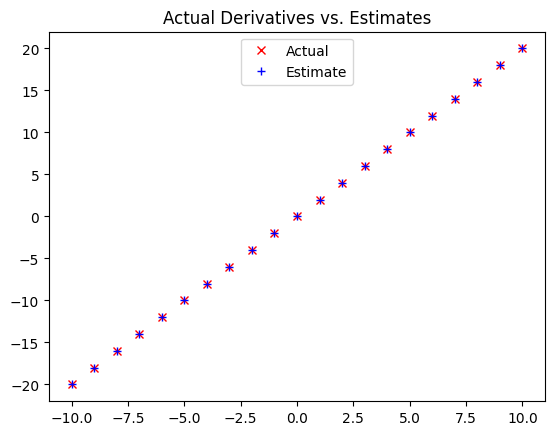

In [57]:
xs = range(-10, 11)
actuals = [derivative(x) for x in xs]
estimates = [difference_quotient(square, x, h = 0.001) for x in xs]

# plot to show they're basically the same
import matplotlib.pyplot as plt 
plt.title("Actual Derivatives vs. Estimates")
plt.plot(xs, actuals, 'rx', label = 'Actual')
plt.plot(xs, estimates, 'b+', label = 'Estimate')
plt.legend(loc=9)
plt.show()

We calculate its *i*th partial derivative by treating it as a function or just its *i*th variable, holding the other variable fixed:

In [58]:
from typing import List
Vector = List[float]

def partial_difference_quotient(f: Callable[[Vector], float],
                                v: Vector,
                                i: int,
                                h: float) -> float:
    
    """Returns the i-th partial difference quotient of f at v"""
    w = [v_j + (h if j == i else 0) for j, v_j in enumerate(v)] # add h to just the i-th element of v
    return (f(w) - f(v)) / h

after which we can estimate the gradient the same way:

In [59]:
def estiamte_gradient(f: Callable[[Vector], float],
                      v: Vector,
                      h: float = 0.0001):
    return [partial_difference_quotient(f, v, i, h) for i in range(len(v))]

## Using the gradient

It's easy to see that the ```sum_of_squares``` function is smallest when its input ```v``` is a vector of zeros. We can use gradients to find the minimum among all three-dimensional vectors. We'll just pick a random starting point and then take tine steps in the opposite direction of the gradient until we reach a point where the gradient is very smll:


In [60]:
import random
from typing import List, Callable
import math

Vector = List[float]

# ── linear algebra helpers ─────────────────────────────────────────
def add(u: Vector, v: Vector) -> Vector:
    assert len(u) == len(v)
    return [u_i + v_i for u_i, v_i in zip(u, v)]

def scalar_multiply(c: float, v: Vector) -> Vector:
    return [c * v_i for v_i in v]

def distance(u: Vector, v: Vector) -> float:
    return math.sqrt(sum((u_i - v_i) ** 2 for u_i, v_i in zip(u, v)))

# ── gradient descent ───────────────────────────────────────────────
def gradient_step(v: Vector, gradient: Vector, step_size: float) -> Vector:
    assert len(v) == len(gradient)
    step = scalar_multiply(step_size, gradient)
    return add(v, step)

def sum_of_squares_gradient(v: Vector) -> Vector:
    return [2 * v_i for v_i in v]

# ── training loop ──────────────────────────────────────────────────
v = [random.uniform(-10, 10) for i in range(3)]

for epoch in range(1000):
    grad = sum_of_squares_gradient(v)
    v = gradient_step(v, grad, -0.01)
    if epoch % 100 == 0:
        print(epoch, v)

assert distance(v, [0, 0, 0]) < 0.001
print("converged:", v)

0 [6.631146596859155, 4.049213795523647, 7.876087982746515]
100 [0.8794197167484649, 0.537004935285254, 1.0445232904598456]
200 [0.11662825228027104, 0.07121735603082104, 0.1385242149025109]
300 [0.01546718702219078, 0.009444814128806012, 0.018371019861040346]
400 [0.002051251473824031, 0.0012525670552707433, 0.002436356495304862]
500 [0.00027203605948700074, 0.00016611488659840467, 0.00032310851640862827]
600 [3.60773013965247e-05, 2.203008248818773e-05, 4.285050795192487e-05]
700 [4.784555689088267e-06, 2.921619755908236e-06, 5.682815334448866e-06]
800 [6.34525650640601e-07, 3.8746391452188756e-07, 7.536524458865019e-07]
900 [8.415050999178588e-08, 5.138529226913534e-08, 9.994905267246239e-08]
converged: [1.1387758432069016e-08, 6.953770041076353e-09, 1.3525713242370665e-08]


## Choosing the Right Step Size

Although the rationale for moving against the gradient is clear, how far to move is not. 
- Using a fixed step size
- Gradually shrinking the step size over time
- At each step, choosing the step size that minimizes the value of the objective function

## Using Gradient Descent to Fit Models

Use gradient descent to fit parameterized models to data. If we think out data is being fixed, then our loss function tells us how good or bad any particular model parameters are. This means we can use gradient descent to find the model parameters that make the loss as small as possible. Let's look at a simple example:


In [61]:
# x ranges from -50 to 49, y is always 20 * x + 5
inputs = [(x, 20 * x + 5) for x in range(-50, 50)]

In this case we know the parameters of the linear relationship between ``x`` and ``y``, but imagine we'd like to learn them from the data. We'll use gradient descent to find the slop and intercept that minimize the average squared error. 

Start off with a function that determines the gradient based on the error from a single data point:

In [62]:
def linear_gradient(x: float, y:float, theta: Vector) -> Vector:
    slope, intercept = theta
    predicted = slope * x + intercept # The prediction of the model
    error = (predicted - y)           # error is (predicted - actual)
    squared_error = error ** 2        # We'll minimize squared error
    grad = [2 * error * x, 2 * error] # Using its gradient
    return grad

## Gradient Interpretation

For a single data point, if our prediction is **too large** the error is positive:

- $2 \cdot \text{error}$ is positive — increasing the intercept makes the prediction larger, increasing squared error
- $2 \cdot \text{error} \cdot x$ has the same sign as $x$:
  - If $x > 0$: increasing slope increases the (already too large) prediction
  - If $x < 0$: increasing slope decreases the prediction, reducing error

## Gradient Descent for Linear Regression

For the full dataset we minimize the **mean squared error (MSE)**. The gradient of the MSE is just the mean of the individual gradients.

### Algorithm

1. Start with a random value for $\theta = (\alpha, \beta)$
2. Compute the mean of the gradients
3. Adjust $\theta$ in the opposite direction of the gradient
4. Repeat for many **epochs** (passes through the dataset)

$$\theta \leftarrow \theta - \alpha \cdot \nabla_\theta \text{MSE}$$


In [63]:
import random 
import numpy as np 
import LinearRegression

inputs = [(x, 20 * x + 5) for x in range(-50, 50)]

theta = [random.uniform(-1, 1), random.uniform(-1, 1)]
learning_rate = 0.001

for epoch in range(5000):
    grads = np.array([linear_gradient(x, y, theta) for x, y in inputs])
    grad  = grads.mean(axis=0)
    theta = gradient_step(theta, grad, -learning_rate)

    if epoch % 500 == 0:
        print(epoch, theta)

slope, intercept = theta
print(f"\nfinal slope: {slope:.4f}, intercept: {intercept:.4f}")

0 [np.float64(32.7691287725274), np.float64(-0.9454064878342111)]
500 [np.float64(19.998688984714654), np.float64(2.817158762505492)]
1000 [np.float64(19.99951804212712), np.float64(4.197539852191447)]
1500 [np.float64(19.999822821752097), np.float64(4.704998110829151)]
2000 [np.float64(19.999934865403606), np.float64(4.891550857881184)]
2500 [np.float64(19.999976055098763), np.float64(4.960131725056532)]
3000 [np.float64(19.999991197330957), np.float64(4.985343550756468)]
3500 [np.float64(19.999996763946466), np.float64(4.994611968921843)]
4000 [np.float64(19.99999881035599), np.float64(4.998019242013074)]
4500 [np.float64(19.99999956266086), np.float64(4.999271830071896)]

final slope: 20.0000, intercept: 4.9997


## Minibatch and StochastiC Gradient Descent 
One drawback of the preceding approach is that we had to evaluate the gradients on the entire dataset before we could take a gradient step and update our parameters. In this case it was fine, because our dataset was only 100 pairs and the gradient computation was cheap. 

Models, however, will frequently have large datasets and expensive gradient computatations. In that case you'll want to take gradient steps more often. 

We can do this using a technique called *minibatch gradient descent*, in which we compute the gradient (and take a gradient step) based on a "minibatch" sampled from the larger dataset:


In [64]:
from typing import TypeVar, List, Iterator 

T = TypeVar('T') # this allows us to type "generic" functions

def minibatches(dataset: List, batch_size: int, shuffle: bool = True):
    batch_starts = [start for start in range(0, len(dataset), batch_size)]
    
    if shuffle: random.shuffle(dataset)  # shuffle the dataset, not batch_size

    for start in batch_starts:
        end = start + batch_size
        yield dataset[start:end]

Now we can solve using minibatches

In [65]:
def vector_mean(vectors: List[Vector]) -> Vector:
    """Component-wise mean of a list of vectors"""
    n = len(vectors)
    return [sum(v[i] for v in vectors) / n for i in range(len(vectors[0]))]

theta = [random.uniform(-1, 1), random.uniform(-1, 1)]

for epoch in range(1000):
    for batch in minibatches(inputs, batch_size=20):
        grad = vector_mean([linear_gradient(x, y, theta) for x, y in batch])
        theta = gradient_step(theta, grad, -learning_rate)
    print(epoch, theta)

slope, intercept = theta


0 [21.44116219502551, 0.4585890984134283]
1 [19.97988377864041, 0.49222177340506673]
2 [19.95589131019883, 0.5378332767276895]
3 [20.061324685969577, 0.583632787336621]
4 [20.020181647431777, 0.6272466099977692]
5 [20.00630637592155, 0.6703480748242656]
6 [19.928178244514925, 0.7146751786514741]
7 [20.10869480075797, 0.7602792483182972]
8 [19.958968755153727, 0.7999620725661395]
9 [19.97441306040209, 0.8413139029127851]
10 [20.184404690480417, 0.8857344763691639]
11 [19.93063458439107, 0.9251492684601832]
12 [19.976201897982364, 0.965399601935586]
13 [20.008549170124418, 1.00523765575898]
14 [20.021156432887715, 1.0448852709917849]
15 [19.986182655463413, 1.0845537370552765]
16 [20.06889856909333, 1.124761979408167]
17 [19.93636805319622, 1.1634919750135564]
18 [19.968707184377593, 1.2022361842979037]
19 [20.01816582115718, 1.2397198628860724]
20 [19.986883386122898, 1.2768932382478742]
21 [19.997548664858716, 1.3137048817493189]
22 [19.971918398448476, 1.3508913623332774]
23 [20.04480

Another version is *stochastic gradient descent*, in which you take gradient steps based on one training example at a time:

In [66]:
theta = [random.uniform(-1, 1), random.uniform(-1, 1)]

for epoch in range(100):
    for x, y in inputs:
        grad = linear_gradient(x, y, theta)
        theta = gradient_step(theta, grad, -learning_rate)
    print(epoch, theta)

slope, intercept = theta
assert 19.9 < slope < 20.1, "Slope shoud be about 20"
assert 4.9 < intercept < 5.1, "Intercept should be about 5"

0 [12460.743953681402, -651.5558030062307]
1 [-794449.5738352132, 41932.84699637447]
2 [50735081.03046325, -2677519.6608477505]
3 [-3239955923.610161, 170987518.62233704]
4 [206904541047.9851, -10919312986.683937]
5 [-13212984942701.207, 697310544409.4636]
6 [843785110897920.0, -44530456788619.64]
7 [-5.388436575530912e+16, 2843728088892044.0]
8 [3.441071471102624e+18, -1.816013134996475e+17]
9 [-2.1974783786092397e+20, 1.1597113378602447e+19]
10 [1.403316166202081e+22, -7.405950767884743e+20]
11 [-8.961618378108713e+23, 4.729461977799732e+22]
12 [5.72291589657997e+25, -3.0202483516970287e+24]
13 [-3.6546709508779443e+27, 1.9287394948404663e+26]
14 [2.3338836356433306e+29, -1.2316987233408214e+28]
15 [-1.4904249651846813e+31, 7.865664332263234e+29]
16 [9.517897734577703e+32, -5.023036414296802e+31]
17 [-6.0781575323823125e+34, 3.207725851694427e+33]
18 [3.8815293060190736e+36, -2.048463178634797e+35]
19 [-2.4787560495457845e+38, 1.3081546205097335e+37]
20 [1.582940915487096e+40, -8.353

OverflowError: (34, 'Result too large')